# ATAC-informed prediction of chromatin contacts in GM12878

This notebook tests whether ATAC-seq accessibility features improve prediction of short-range Hi-C contact intensity beyond genomic distance alone. It uses a chromosome-level split: chromosomes 16–19 for training, chromosome 20 for model selection, and the chromosome 21 long arm for the final held-out test.

**Headline result:** the selected pairwise model reduced held-out chromosome 21 MSE by 23.59% and MAE by 27.92% relative to a distance-only baseline (Pearson r = 0.739; Spearman rho = 0.816; ATAC-feature permutation p = 0.0099).

> This is an exploratory proof of concept, not a replacement for Hi-C or evidence that accessibility causes chromatin contacts. See the repository README for limitations.


## 1. Setup and ENCODE data access


In [ ]:
# Install dependencies in Google Colab
!pip -q install hic-straw pyBigWig scikit-learn scipy pandas joblib

from pathlib import Path
import hicstraw

HIC_URL = "https://www.encodeproject.org/files/ENCFF916GWS/@@download/ENCFF916GWS.hic"
ATAC_URL = "https://www.encodeproject.org/files/ENCFF667MDI/@@download/ENCFF667MDI.bigWig"
ATAC_PATH = Path("/content/ENCFF667MDI.bigWig")

# The ATAC bigWig is about 1.3 GB. Download it once per Colab runtime.
if not ATAC_PATH.exists() or ATAC_PATH.stat().st_size < 1_000_000_000:
    !wget -q --show-progress -O /content/ENCFF667MDI.bigWig "$ATAC_URL"

hic = hicstraw.HiCFile(HIC_URL)
print("Genome:", hic.getGenomeID())
print("ATAC file:", f"{ATAC_PATH.stat().st_size / 1e9:.2f} GB")


## 2. Extract matched 100 kb ATAC-seq and Hi-C arrays

The raw ENCODE files are not committed because of their size.


In [ ]:
import numpy as np
import pyBigWig

resolution = 100_000
chromosomes_to_extract = [
    "chr16",
    "chr17",
    "chr18",
    "chr19",
    "chr20",
    "chr21"
]

# Obtain chromosome lengths from the Hi-C file
chromosome_lengths = {
    chromosome.name: chromosome.length
    for chromosome in hic.getChromosomes()
}

atac_file = pyBigWig.open("/content/ENCFF667MDI.bigWig")

multi_chromosome_data = {}

for chromosome in chromosomes_to_extract:
    length = chromosome_lengths[chromosome]

    print(f"Extracting {chromosome} Hi-C...")

    hic_data = hic.getMatrixZoomData(
        chromosome,
        chromosome,
        "observed",
        "NONE",
        "BP",
        resolution
    )

    hic_matrix = hic_data.getRecordsAsMatrix(
        0,
        length,
        0,
        length
    )

    hic_matrix = np.nan_to_num(
        hic_matrix,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    print(f"Extracting {chromosome} ATAC-seq...")

    atac_values = atac_file.stats(
        chromosome,
        0,
        length,
        nBins=hic_matrix.shape[0],
        type="mean"
    )

    atac_values = np.array(
        [0.0 if value is None else value for value in atac_values],
        dtype=float
    )
    atac_values = np.nan_to_num(atac_values)

    multi_chromosome_data[f"{chromosome}_ATAC"] = atac_values
    multi_chromosome_data[f"{chromosome}_HiC"] = hic_matrix

    print(
        f"{chromosome} complete:",
        "ATAC", atac_values.shape,
        "Hi-C", hic_matrix.shape
    )

atac_file.close()

# Save all extracted chromosomes
np.savez_compressed(
    "/content/GM12878_multichromosome_data.npz",
    **multi_chromosome_data
)

print("\nAll chromosomes extracted successfully.")

Extracting chr16 Hi-C...
Extracting chr16 ATAC-seq...
chr16 complete: ATAC (904,) Hi-C (904, 904)
Extracting chr17 Hi-C...
Extracting chr17 ATAC-seq...
chr17 complete: ATAC (833,) Hi-C (833, 833)
Extracting chr18 Hi-C...
Extracting chr18 ATAC-seq...
chr18 complete: ATAC (804,) Hi-C (804, 804)
Extracting chr19 Hi-C...
Extracting chr19 ATAC-seq...
chr19 complete: ATAC (587,) Hi-C (587, 587)
Extracting chr20 Hi-C...
Extracting chr20 ATAC-seq...
chr20 complete: ATAC (645,) Hi-C (645, 645)
Extracting chr21 Hi-C...
Extracting chr21 ATAC-seq...
chr21 complete: ATAC (468,) Hi-C (468, 468)

All chromosomes extracted successfully.


In [ ]:
# Load the extracted matrices created above
data = np.load("/content/GM12878_multichromosome_data.npz")
print("Loaded arrays:", sorted(data.files))


## 3. Create pairwise features and chromosome-level splits


In [ ]:
import numpy as np

# Predict interactions up to 1.5 Mb apart:
# 15 bins × 100 kb = 1.5 Mb
maximum_distance_bins = 15

training_chromosomes = ["chr16", "chr17", "chr18", "chr19"]
validation_chromosomes = ["chr20"]
test_chromosomes = ["chr21"]

def create_pairwise_dataset(
    chromosomes,
    chromosome_minimum_bins=None
):
    if chromosome_minimum_bins is None:
        chromosome_minimum_bins = {}

    full_features = []
    distance_features = []
    targets = []
    metadata = []

    for chromosome in chromosomes:
        atac = np.asarray(
            data[f"{chromosome}_ATAC"],
            dtype=float
        )
        hic = np.asarray(
            data[f"{chromosome}_HiC"],
            dtype=float
        )

        # Compress extreme accessibility values
        atac = np.log1p(np.clip(atac, 0, None))

        # Identify bins with measurable Hi-C coverage
        hic_coverage = np.sum(hic, axis=1) > 0

        minimum_bin = chromosome_minimum_bins.get(
            chromosome,
            0
        )

        for distance in range(
            1,
            maximum_distance_bins + 1
        ):
            bin_a = np.arange(
                minimum_bin,
                len(atac) - distance
            )
            bin_b = bin_a + distance

            valid = (
                hic_coverage[bin_a]
                & hic_coverage[bin_b]
            )

            bin_a = bin_a[valid]
            bin_b = bin_b[valid]

            accessibility_a = atac[bin_a]
            accessibility_b = atac[bin_b]

            lower_accessibility = np.minimum(
                accessibility_a,
                accessibility_b
            )
            higher_accessibility = np.maximum(
                accessibility_a,
                accessibility_b
            )

            pair_features = np.column_stack([
                np.full(len(bin_a), distance),
                lower_accessibility,
                higher_accessibility,
                (
                    accessibility_a
                    + accessibility_b
                ) / 2,
                np.abs(
                    accessibility_a
                    - accessibility_b
                ),
                accessibility_a * accessibility_b
            ])

            pair_targets = np.log1p(
                hic[bin_a, bin_b]
            )

            full_features.append(pair_features)
            distance_features.append(
                np.full((len(bin_a), 1), distance)
            )
            targets.append(pair_targets)

            metadata.extend([
                (chromosome, int(a), int(b), distance)
                for a, b in zip(bin_a, bin_b)
            ])

    return (
        np.vstack(full_features).astype(np.float32),
        np.vstack(distance_features).astype(np.float32),
        np.concatenate(targets).astype(np.float32),
        metadata
    )

# Training: chromosomes 16–19
X_train_full, X_train_distance, y_train, train_pairs = (
    create_pairwise_dataset(training_chromosomes)
)

# Validation: chromosome 20
X_val_full, X_val_distance, y_val, val_pairs = (
    create_pairwise_dataset(validation_chromosomes)
)

# Final test: chromosome 21 long arm only
X_test_full, X_test_distance, y_test, test_pairs = (
    create_pairwise_dataset(
        test_chromosomes,
        chromosome_minimum_bins={"chr21": 130}
    )
)

print("Full feature columns:")
print(
    "distance, lower ATAC, higher ATAC, "
    "mean ATAC, ATAC difference, ATAC product"
)

print("\nTraining pairs:", X_train_full.shape)
print("Validation pairs:", X_val_full.shape)
print("Test pairs:", X_test_full.shape)

print("\nTraining zero-contact proportion:",
      np.mean(y_train == 0))
print("Validation zero-contact proportion:",
      np.mean(y_val == 0))
print("Test zero-contact proportion:",
      np.mean(y_test == 0))

assert X_train_full.shape[1] == 6
assert len(X_train_full) == len(y_train)
assert len(X_test_full) == len(y_test)

print("\nPairwise dataset created successfully.")

Full feature columns:
distance, lower ATAC, higher ATAC, mean ATAC, ATAC difference, ATAC product

Training pairs: (44427, 6)
Validation pairs: (9540, 6)
Test pairs: (4935, 6)

Training zero-contact proportion: 0.04526526661714723
Validation zero-contact proportion: 0.03962264150943396
Test zero-contact proportion: 0.007902735562310031

Pairwise dataset created successfully.


## 4. Train and evaluate the gradient-boosted model


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr
import numpy as np

# Build a direct distance-dependent baseline using training data only
distance_means = {}

for distance in range(1, maximum_distance_bins + 1):
    mask = X_train_distance[:, 0] == distance
    distance_means[distance] = y_train[mask].mean()

def predict_distance_baseline(distance_features):
    return np.array([
        distance_means[int(distance)]
        for distance in distance_features[:, 0]
    ])

validation_baseline = predict_distance_baseline(
    X_val_distance
)
test_baseline = predict_distance_baseline(
    X_test_distance
)

print(
    "Distance baseline validation MSE:",
    mean_squared_error(y_val, validation_baseline)
)

# Select the ATAC model using chromosome 20
candidate_settings = [
    (7, 0.1),
    (15, 0.1),
    (15, 1.0),
    (31, 1.0),
    (31, 10.0)
]

best_pairwise_model = None
best_settings = None
best_validation_mse = np.inf

for maximum_leaves, regularisation in candidate_settings:
    candidate = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=250,
        max_leaf_nodes=maximum_leaves,
        l2_regularization=regularisation,
        random_state=42
    )

    candidate.fit(X_train_full, y_train)

    validation_prediction = candidate.predict(
        X_val_full
    )
    validation_prediction = np.clip(
        validation_prediction,
        0,
        None
    )

    validation_mse = mean_squared_error(
        y_val,
        validation_prediction
    )

    print(
        f"Leaves={maximum_leaves:2}, "
        f"L2={regularisation:4}: "
        f"validation MSE={validation_mse:.4f}"
    )

    if validation_mse < best_validation_mse:
        best_validation_mse = validation_mse
        best_pairwise_model = candidate
        best_settings = (
            maximum_leaves,
            regularisation
        )

print("\nBest settings:", best_settings)
print("Best ATAC-model validation MSE:",
      best_validation_mse)

# Test once on unseen chromosome 21
test_prediction = best_pairwise_model.predict(
    X_test_full
)
test_prediction = np.clip(test_prediction, 0, None)

baseline_mse = mean_squared_error(
    y_test,
    test_baseline
)
model_mse = mean_squared_error(
    y_test,
    test_prediction
)

baseline_mae = mean_absolute_error(
    y_test,
    test_baseline
)
model_mae = mean_absolute_error(
    y_test,
    test_prediction
)

pearson = pearsonr(
    y_test,
    test_prediction
).statistic

spearman = spearmanr(
    y_test,
    test_prediction
).statistic

mse_improvement = (
    (baseline_mse - model_mse)
    / baseline_mse
    * 100
)

mae_improvement = (
    (baseline_mae - model_mae)
    / baseline_mae
    * 100
)

print("\nIndependent chromosome 21 test")
print(f"Distance baseline MSE: {baseline_mse:.4f}")
print(f"ATAC model MSE:        {model_mse:.4f}")
print(f"MSE improvement:       {mse_improvement:.2f}%")
print(f"Distance baseline MAE: {baseline_mae:.4f}")
print(f"ATAC model MAE:        {model_mae:.4f}")
print(f"MAE improvement:       {mae_improvement:.2f}%")
print(f"Pearson correlation:   {pearson:.4f}")
print(f"Spearman correlation:  {spearman:.4f}")

Distance baseline validation MSE: 1.9290987253189087
Leaves= 7, L2= 0.1: validation MSE=0.5385
Leaves=15, L2= 0.1: validation MSE=0.5522
Leaves=15, L2= 1.0: validation MSE=0.5525
Leaves=31, L2= 1.0: validation MSE=0.5804
Leaves=31, L2=10.0: validation MSE=0.5772

Best settings: (7, 0.1)
Best ATAC-model validation MSE: 0.5385447982256997

Independent chromosome 21 test
Distance baseline MSE: 1.2101
ATAC model MSE:        0.9051
MSE improvement:       25.20%
Distance baseline MAE: 0.8085
ATAC model MAE:        0.5696
MAE improvement:       29.55%
Pearson correlation:   0.7402
Spearman correlation:  0.8185


## 5. Test whether ATAC features contribute information


Observed ATAC-model MSE: 0.9051
Mean shuffled-ATAC MSE: 1.2525
Shuffled MSE range: 1.2177 to 1.2839
Permutation p-value: 0.0099


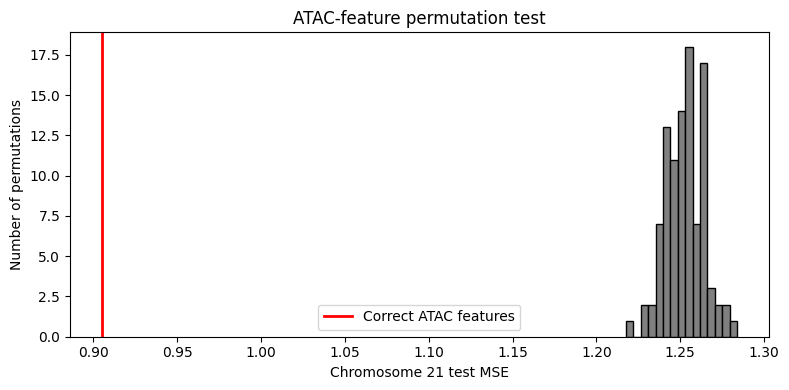

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
number_of_permutations = 100
permuted_mse_values = []

observed_mse = mean_squared_error(
    y_test,
    test_prediction
)

for permutation in range(number_of_permutations):
    shuffled_features = X_test_full.copy()

    # Preserve genomic distance but break its association
    # with the five ATAC-derived features
    shuffled_order = rng.permutation(
        len(shuffled_features)
    )
    shuffled_features[:, 1:] = (
        shuffled_features[shuffled_order, 1:]
    )

    shuffled_prediction = (
        best_pairwise_model.predict(
            shuffled_features
        )
    )
    shuffled_prediction = np.clip(
        shuffled_prediction,
        0,
        None
    )

    shuffled_mse = mean_squared_error(
        y_test,
        shuffled_prediction
    )
    permuted_mse_values.append(shuffled_mse)

permuted_mse_values = np.array(
    permuted_mse_values
)

permutation_p_value = (
    1
    + np.sum(permuted_mse_values <= observed_mse)
) / (
    number_of_permutations + 1
)

print(f"Observed ATAC-model MSE: {observed_mse:.4f}")
print(
    "Mean shuffled-ATAC MSE:",
    f"{permuted_mse_values.mean():.4f}"
)
print(
    "Shuffled MSE range:",
    f"{permuted_mse_values.min():.4f}",
    "to",
    f"{permuted_mse_values.max():.4f}"
)
print(
    "Permutation p-value:",
    f"{permutation_p_value:.4f}"
)

plt.figure(figsize=(8, 4))
plt.hist(
    permuted_mse_values,
    bins=15,
    color="grey",
    edgecolor="black"
)
plt.axvline(
    observed_mse,
    color="red",
    linewidth=2,
    label="Correct ATAC features"
)
plt.xlabel("Chromosome 21 test MSE")
plt.ylabel("Number of permutations")
plt.title("ATAC-feature permutation test")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Exploratory leave-one-chromosome-out analysis


chr16 pairs: 11988
chr17 pairs: 12330
chr18 pairs: 11925
chr19 pairs: 8184
chr20 pairs: 9540
chr21 pairs: 4935
chr16: MSE improvement=31.20%, MAE improvement=26.08%, Pearson=0.728
chr17: MSE improvement=61.56%, MAE improvement=35.15%, Pearson=0.865
chr18: MSE improvement=87.63%, MAE improvement=57.06%, Pearson=0.955
chr19: MSE improvement=0.03%, MAE improvement=6.45%, Pearson=0.827
chr20: MSE improvement=72.38%, MAE improvement=39.71%, Pearson=0.910
chr21: MSE improvement=23.59%, MAE improvement=27.92%, Pearson=0.739

Chromosomes with improved MSE: 6 of 6
Mean MSE improvement: 46.06%
Mean MAE improvement: 32.06%


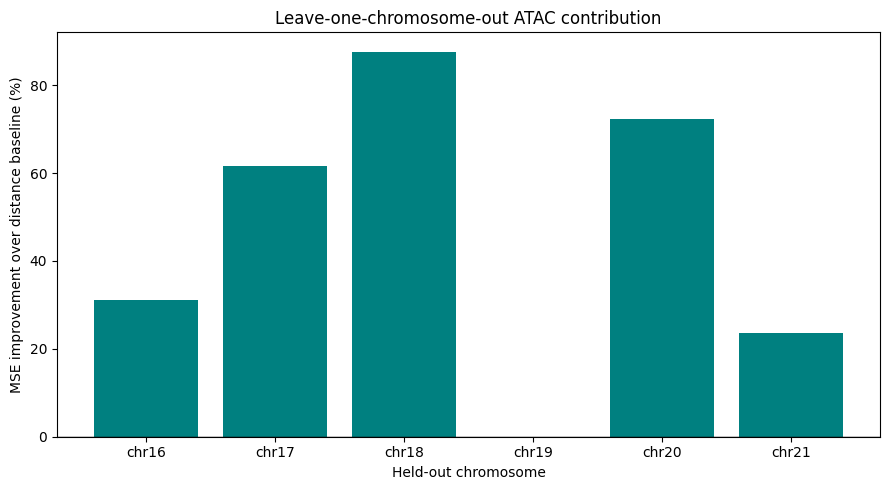

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr

chromosomes = [
    "chr16", "chr17", "chr18",
    "chr19", "chr20", "chr21"
]

# Create and cache a separate dataset for every chromosome
chromosome_datasets = {}

for chromosome in chromosomes:
    minimum_bins = (
        {"chr21": 130}
        if chromosome == "chr21"
        else {}
    )

    full, distance, target, metadata = (
        create_pairwise_dataset(
            [chromosome],
            chromosome_minimum_bins=minimum_bins
        )
    )

    chromosome_datasets[chromosome] = {
        "full": full,
        "distance": distance,
        "target": target,
        "metadata": metadata
    }

    print(
        chromosome,
        "pairs:",
        len(target)
    )

results = []

# Use the previously selected fixed model settings
fixed_leaves = 7
fixed_l2 = 0.1

for held_out in chromosomes:
    training_set = [
        chromosome
        for chromosome in chromosomes
        if chromosome != held_out
    ]

    fold_X = np.vstack([
        chromosome_datasets[c]["full"]
        for c in training_set
    ])

    fold_distance = np.vstack([
        chromosome_datasets[c]["distance"]
        for c in training_set
    ])

    fold_y = np.concatenate([
        chromosome_datasets[c]["target"]
        for c in training_set
    ])

    test_X = chromosome_datasets[held_out]["full"]
    test_distance = chromosome_datasets[held_out]["distance"]
    test_y = chromosome_datasets[held_out]["target"]

    # Distance-only baseline fitted without the held-out chromosome
    fold_distance_means = {}

    for distance in range(
        1,
        maximum_distance_bins + 1
    ):
        mask = fold_distance[:, 0] == distance
        fold_distance_means[distance] = (
            fold_y[mask].mean()
        )

    fold_baseline_prediction = np.array([
        fold_distance_means[int(distance)]
        for distance in test_distance[:, 0]
    ])

    # Distance + ATAC model
    fold_model = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=250,
        max_leaf_nodes=fixed_leaves,
        l2_regularization=fixed_l2,
        random_state=42
    )

    fold_model.fit(fold_X, fold_y)

    fold_prediction = fold_model.predict(test_X)
    fold_prediction = np.clip(
        fold_prediction,
        0,
        None
    )

    baseline_mse = mean_squared_error(
        test_y,
        fold_baseline_prediction
    )
    atac_mse = mean_squared_error(
        test_y,
        fold_prediction
    )

    baseline_mae = mean_absolute_error(
        test_y,
        fold_baseline_prediction
    )
    atac_mae = mean_absolute_error(
        test_y,
        fold_prediction
    )

    mse_improvement = (
        (baseline_mse - atac_mse)
        / baseline_mse
        * 100
    )

    mae_improvement = (
        (baseline_mae - atac_mae)
        / baseline_mae
        * 100
    )

    pearson = pearsonr(
        test_y,
        fold_prediction
    ).statistic

    spearman = spearmanr(
        test_y,
        fold_prediction
    ).statistic

    results.append({
        "chromosome": held_out,
        "pairs": len(test_y),
        "baseline_mse": baseline_mse,
        "atac_mse": atac_mse,
        "mse_improvement": mse_improvement,
        "baseline_mae": baseline_mae,
        "atac_mae": atac_mae,
        "mae_improvement": mae_improvement,
        "pearson": pearson,
        "spearman": spearman
    })

    print(
        f"{held_out}: "
        f"MSE improvement={mse_improvement:.2f}%, "
        f"MAE improvement={mae_improvement:.2f}%, "
        f"Pearson={pearson:.3f}"
    )

# Summarise
mse_improvements = np.array([
    result["mse_improvement"]
    for result in results
])

mae_improvements = np.array([
    result["mae_improvement"]
    for result in results
])

print("\nChromosomes with improved MSE:",
      np.sum(mse_improvements > 0),
      "of",
      len(results))

print("Mean MSE improvement:",
      f"{mse_improvements.mean():.2f}%")

print("Mean MAE improvement:",
      f"{mae_improvements.mean():.2f}%")

# Plot improvement by held-out chromosome
plt.figure(figsize=(9, 5))
colours = [
    "teal" if value > 0 else "firebrick"
    for value in mse_improvements
]

plt.bar(
    [result["chromosome"] for result in results],
    mse_improvements,
    color=colours
)

plt.axhline(0, color="black", linewidth=1)
plt.ylabel("MSE improvement over distance baseline (%)")
plt.xlabel("Held-out chromosome")
plt.title("Leave-one-chromosome-out ATAC contribution")
plt.tight_layout()
plt.show()

## 7. Performance by genomic distance


 100 kb: pairs= 336, improvement=   7.02%
 200 kb: pairs= 335, improvement=   2.95%
 300 kb: pairs= 334, improvement=   5.27%
 400 kb: pairs= 333, improvement=   9.37%
 500 kb: pairs= 332, improvement=  11.90%
 600 kb: pairs= 331, improvement=  20.72%
 700 kb: pairs= 330, improvement=  26.78%
 800 kb: pairs= 329, improvement=  29.56%
 900 kb: pairs= 328, improvement=  35.13%
1000 kb: pairs= 327, improvement=  37.17%
1100 kb: pairs= 326, improvement=  37.79%
1200 kb: pairs= 325, improvement=  37.55%
1300 kb: pairs= 324, improvement=  37.44%
1400 kb: pairs= 323, improvement=  39.33%
1500 kb: pairs= 322, improvement=  39.09%


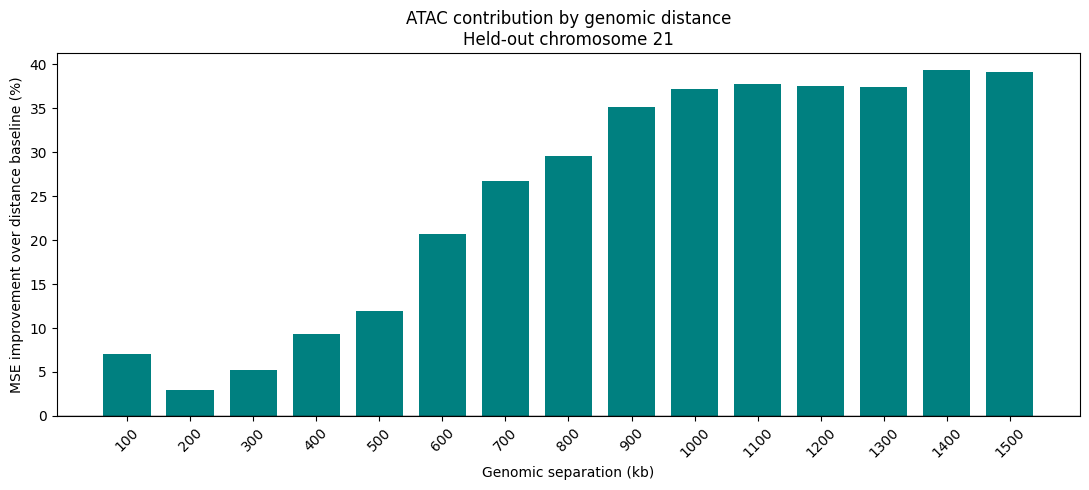

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

distance_results = []

for distance in range(
    1,
    maximum_distance_bins + 1
):
    mask = X_test_distance[:, 0] == distance

    distance_baseline_mse = mean_squared_error(
        y_test[mask],
        test_baseline[mask]
    )

    distance_model_mse = mean_squared_error(
        y_test[mask],
        test_prediction[mask]
    )

    distance_improvement = (
        (
            distance_baseline_mse
            - distance_model_mse
        )
        / distance_baseline_mse
        * 100
    )

    distance_results.append({
        "distance_bins": distance,
        "distance_kb": distance * 100,
        "number_of_pairs": int(mask.sum()),
        "baseline_mse": distance_baseline_mse,
        "model_mse": distance_model_mse,
        "improvement": distance_improvement
    })

    print(
        f"{distance * 100:4} kb: "
        f"pairs={mask.sum():4}, "
        f"improvement={distance_improvement:7.2f}%"
    )

distances_kb = [
    result["distance_kb"]
    for result in distance_results
]

improvements = [
    result["improvement"]
    for result in distance_results
]

colours = [
    "teal" if value > 0 else "firebrick"
    for value in improvements
]

plt.figure(figsize=(11, 5))
plt.bar(
    distances_kb,
    improvements,
    width=75,
    color=colours
)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Genomic separation (kb)")
plt.ylabel("MSE improvement over distance baseline (%)")
plt.title(
    "ATAC contribution by genomic distance\n"
    "Held-out chromosome 21"
)
plt.xticks(
    distances_kb,
    rotation=45
)
plt.tight_layout()
plt.show()

## 8. Final figures


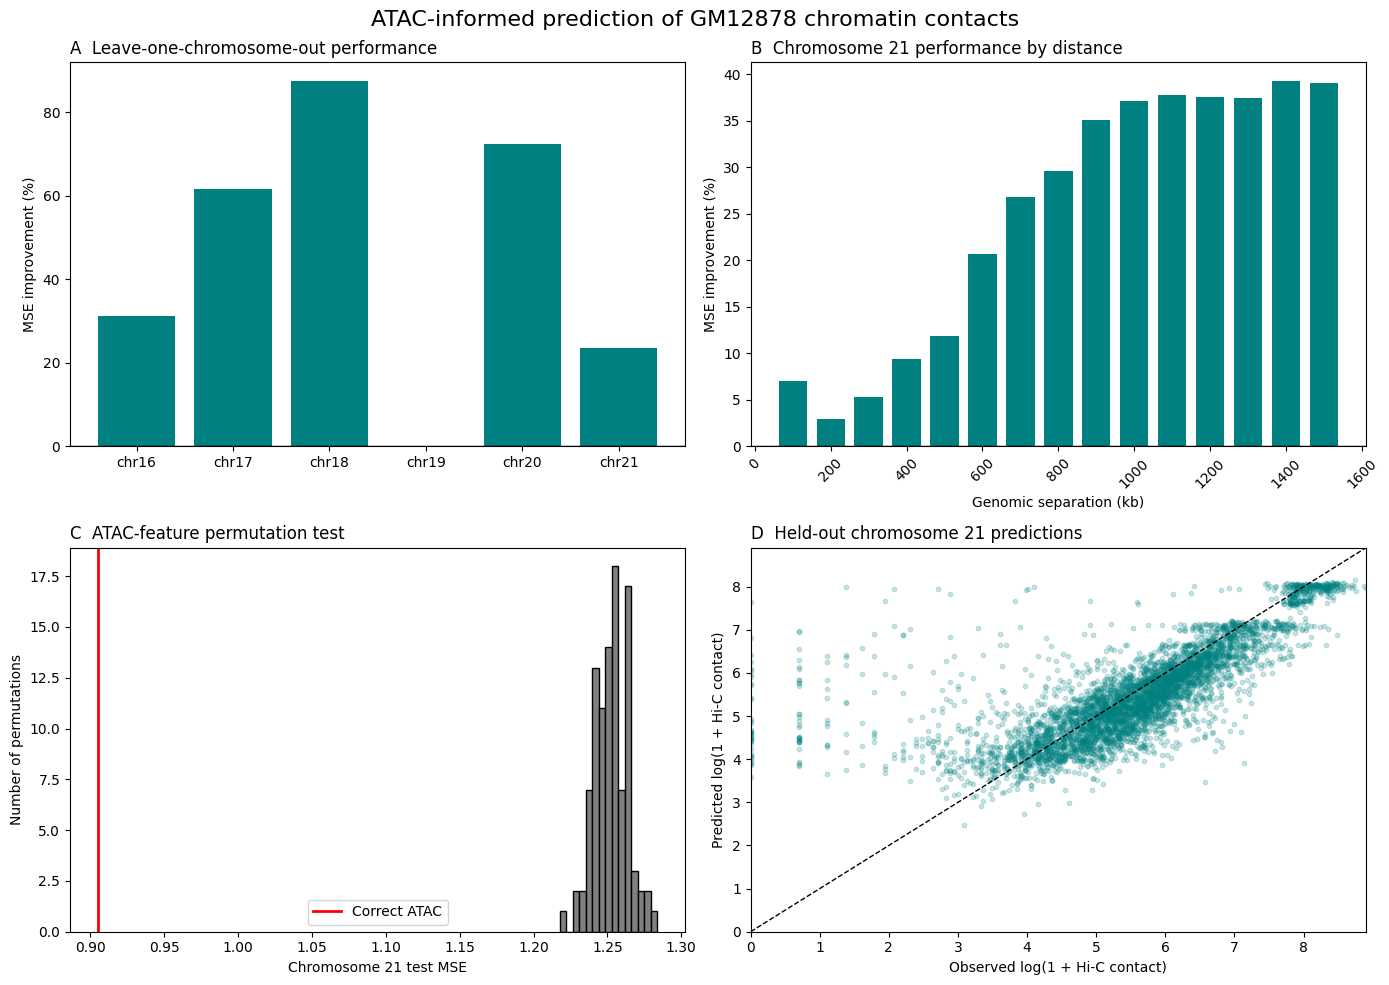

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

# A: Leave-one-chromosome-out performance
chromosome_names = [
    result["chromosome"]
    for result in results
]

axes[0, 0].bar(
    chromosome_names,
    mse_improvements,
    color="teal"
)
axes[0, 0].axhline(
    0,
    color="black",
    linewidth=1
)
axes[0, 0].set_ylabel(
    "MSE improvement (%)"
)
axes[0, 0].set_title(
    "A  Leave-one-chromosome-out performance",
    loc="left"
)

# B: Performance by genomic distance
axes[0, 1].bar(
    distances_kb,
    improvements,
    width=75,
    color="teal"
)
axes[0, 1].axhline(
    0,
    color="black",
    linewidth=1
)
axes[0, 1].set_xlabel(
    "Genomic separation (kb)"
)
axes[0, 1].set_ylabel(
    "MSE improvement (%)"
)
axes[0, 1].set_title(
    "B  Chromosome 21 performance by distance",
    loc="left"
)
axes[0, 1].tick_params(
    axis="x",
    rotation=45
)

# C: ATAC permutation test
axes[1, 0].hist(
    permuted_mse_values,
    bins=15,
    color="grey",
    edgecolor="black"
)
axes[1, 0].axvline(
    observed_mse,
    color="red",
    linewidth=2,
    label="Correct ATAC"
)
axes[1, 0].set_xlabel(
    "Chromosome 21 test MSE"
)
axes[1, 0].set_ylabel(
    "Number of permutations"
)
axes[1, 0].set_title(
    "C  ATAC-feature permutation test",
    loc="left"
)
axes[1, 0].legend()

# D: Predicted versus observed contacts
axes[1, 1].scatter(
    y_test,
    test_prediction,
    s=10,
    alpha=0.2,
    color="teal"
)

plot_limit = max(
    y_test.max(),
    test_prediction.max()
)

axes[1, 1].plot(
    [0, plot_limit],
    [0, plot_limit],
    linestyle="--",
    color="black",
    linewidth=1
)
axes[1, 1].set_xlim(0, plot_limit)
axes[1, 1].set_ylim(0, plot_limit)
axes[1, 1].set_xlabel(
    "Observed log(1 + Hi-C contact)"
)
axes[1, 1].set_ylabel(
    "Predicted log(1 + Hi-C contact)"
)
axes[1, 1].set_title(
    "D  Held-out chromosome 21 predictions",
    loc="left"
)

fig.suptitle(
    "ATAC-informed prediction of GM12878 chromatin contacts",
    fontsize=16
)

plt.tight_layout()
plt.savefig(
    "/content/ATAC_HiC_final_summary_figure.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

files.download(
    "/content/ATAC_HiC_final_summary_figure.png"
)

**Figure 1 | ATAC-informed prediction of short-range Hi-C contacts.**
(A) Percentage reduction in mean-squared error relative to a genomic-distance baseline during exploratory leave-one-chromosome-out evaluation. (B) Performance improvement across genomic separations of 100 kb–1.5 Mb on held-out chromosome 21. (C) Permutation analysis comparing correctly paired ATAC features with 100 shuffled controls; the empirical permutation p-value was 0.0099. (D) Predicted versus observed log-transformed contacts on chromosome 21. The dashed line represents perfect agreement. Predictions remained biased for low-contact pairs, highlighting incomplete calibration.

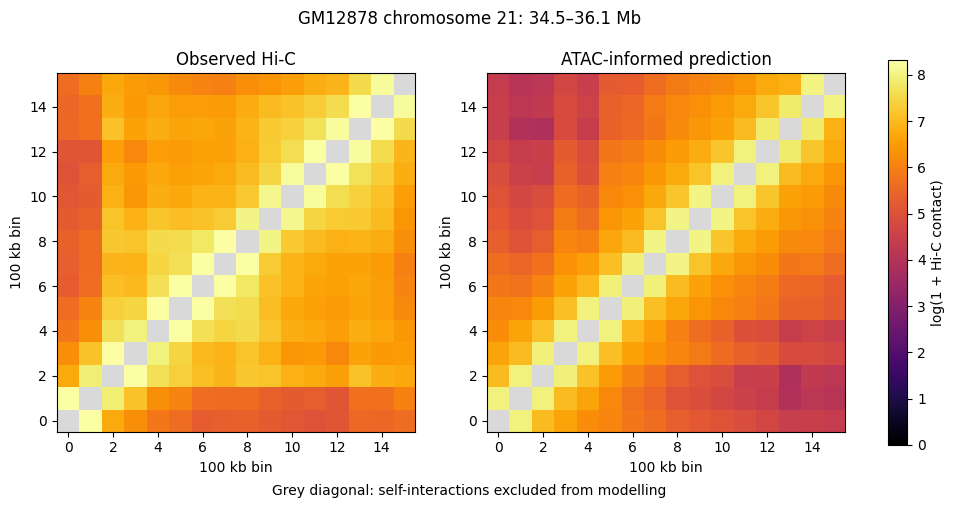

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

chromosome_length_bins = len(
    data["chr21_ATAC"]
)

observed_map = np.full(
    (chromosome_length_bins, chromosome_length_bins),
    np.nan
)
predicted_map = np.full(
    (chromosome_length_bins, chromosome_length_bins),
    np.nan
)

# Reconstruct symmetrical matrices from pairwise results
for index, pair in enumerate(test_pairs):
    chromosome, bin_a, bin_b, distance = pair

    observed_map[bin_a, bin_b] = y_test[index]
    observed_map[bin_b, bin_a] = y_test[index]

    predicted_map[bin_a, bin_b] = test_prediction[index]
    predicted_map[bin_b, bin_a] = test_prediction[index]


import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Use 16 bins so every off-diagonal pair is within
# the model's maximum 1.5 Mb prediction distance
window_size_bins = 16

best_start = None
best_score = -np.inf

for start in range(
    130,
    chromosome_length_bins - window_size_bins
):
    end = start + window_size_bins
    candidate = observed_map[start:end, start:end]
    score = np.nansum(candidate)

    if score > best_score:
        best_score = score
        best_start = start

best_end = best_start + window_size_bins

observed_window = observed_map[
    best_start:best_end,
    best_start:best_end
]

predicted_window = predicted_map[
    best_start:best_end,
    best_start:best_end
]

valid_values = np.concatenate([
    observed_window[np.isfinite(observed_window)],
    predicted_window[np.isfinite(predicted_window)]
])

vmax = np.percentile(valid_values, 98)

# Grey indicates excluded/not-modelled cells
cmap = plt.cm.inferno.copy()
cmap.set_bad("#D9D9D9")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5)
)

axes[0].imshow(
    observed_window,
    cmap=cmap,
    origin="lower",
    vmin=0,
    vmax=vmax
)
axes[0].set_title("Observed Hi-C")

image = axes[1].imshow(
    predicted_window,
    cmap=cmap,
    origin="lower",
    vmin=0,
    vmax=vmax
)
axes[1].set_title("ATAC-informed prediction")

for axis in axes:
    axis.set_xlabel("100 kb bin")
    axis.set_ylabel("100 kb bin")

start_mb = best_start * 0.1
end_mb = best_end * 0.1

fig.suptitle(
    f"GM12878 chromosome 21: "
    f"{start_mb:.1f}–{end_mb:.1f} Mb"
)

fig.colorbar(
    image,
    ax=axes,
    label="log(1 + Hi-C contact)",
    fraction=0.025
)

fig.text(
    0.5,
    0.01,
    "Grey diagonal: self-interactions excluded from modelling",
    ha="center",
    fontsize=10
)

plt.savefig(
    "/content/chr21_observed_vs_predicted_1p6Mb.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

files.download(
    "/content/chr21_observed_vs_predicted_1p6Mb.png"
)


## 9. Export model and result files


In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import joblib
import json
import zipfile

# Save the chromosome 21 pairwise model
joblib.dump(
    best_pairwise_model,
    "/content/pairwise_ATAC_HiC_model.joblib"
)

# Save leave-one-chromosome-out results
chromosome_results_table = pd.DataFrame(results)
chromosome_results_table.to_csv(
    "/content/chromosome_holdout_results.csv",
    index=False
)

# Save distance-stratified results
distance_results_table = pd.DataFrame(
    distance_results
)
distance_results_table.to_csv(
    "/content/distance_stratified_results.csv",
    index=False
)

# Save permutation-test values
np.save(
    "/content/ATAC_permutation_MSE_values.npy",
    permuted_mse_values
)

# Save chromosome 21 predictions
np.savez_compressed(
    "/content/chromosome21_pairwise_predictions.npz",
    observed=y_test,
    predicted=test_prediction,
    distance_baseline=test_baseline,
    features=X_test_full
)

# Save a concise summary
final_summary = {
    "project": "ATAC-informed prediction of Hi-C contacts",
    "cell_line": "GM12878",
    "resolution_bp": 100000,
    "maximum_separation_bp": 1500000,
    "training_chromosomes": [
        "chr16", "chr17", "chr18", "chr19"
    ],
    "validation_chromosome": "chr20",
    "independent_test_chromosome": "chr21",
    "chromosome21_mse_improvement_percent":
        float(mse_improvement),
    "chromosome21_mae_improvement_percent":
        float(mae_improvement),
    "chromosome21_pearson": float(pearson),
    "chromosome21_spearman": float(spearman),
    "permutation_p_value":
        float(permutation_p_value),
    "mean_leave_one_chromosome_out_mse_improvement":
        float(mse_improvements.mean()),
    "conclusion": (
        "ATAC-derived features improved short-range "
        "Hi-C contact prediction beyond genomic distance."
    )
}

with open(
    "/content/final_results_summary.json",
    "w"
) as file:
    json.dump(final_summary, file, indent=2)

# Package the final deliverables
with zipfile.ZipFile(
    "/content/ATAC_HiC_computational_biology_project.zip",
    "w"
) as archive:
    archive.write(
        "/content/pairwise_ATAC_HiC_model.joblib",
        arcname="pairwise_ATAC_HiC_model.joblib"
    )
    archive.write(
        "/content/chromosome_holdout_results.csv",
        arcname="chromosome_holdout_results.csv"
    )
    archive.write(
        "/content/distance_stratified_results.csv",
        arcname="distance_stratified_results.csv"
    )
    archive.write(
        "/content/ATAC_permutation_MSE_values.npy",
        arcname="ATAC_permutation_MSE_values.npy"
    )
    archive.write(
        "/content/chromosome21_pairwise_predictions.npz",
        arcname="chromosome21_pairwise_predictions.npz"
    )
    archive.write(
        "/content/final_results_summary.json",
        arcname="final_results_summary.json"
    )

files.download(
    "/content/ATAC_HiC_computational_biology_project.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>